# 04 - VAR and Granger Causality

This notebook estimates a VAR model on stationary transformed data, tests whether CAC40, S&P500, and exchange rates help predict MASI, and evaluates model diagnostics.

In [11]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, PROCESSED_DATA_DIR, RAW_DATA_DIR, RESULTS_DIR, SERIES_FILES
from src.utils import configure_logging, ensure_directory

configure_logging()
sns.set_theme(style="whitegrid")
ensure_directory(PROCESSED_DATA_DIR)
ensure_directory(RESULTS_DIR)
ensure_directory(FIGURES_DIR)

import statsmodels.api as sm

from src.diagnostics import summarize_var_diagnostics
from src.var_model import (
    fit_var,
    granger_causality_matrix,
    impulse_response_analysis,
    run_targeted_causality_suite,
    select_optimal_lag,
    variance_decomposition,
)

## Load Stationary Data

Returns are the default VAR input. If stationarity tests favor first differences for a specific dataset, replace this file with `market_data_first_difference.csv`.

In [12]:
var_data = pd.read_csv(PROCESSED_DATA_DIR / "market_data_returns.csv", parse_dates=["Date"], index_col="Date")
var_data = var_data.dropna()
var_data.head()

,MASI,CAC40,SP500,EUR_MAD,USD_MAD
Date,,,,,
2015-01-06,0.000891,-0.039694,-0.027014,0.000100,0.009644
2015-01-07,0.010207,0.007158,0.011635,-0.001725,0.002496
2015-01-08,0.005494,0.035855,0.017869,-0.000860,0.003086
2015-01-09,0.019311,-0.019041,-0.008390,0.000421,-0.003724
2015-01-12,0.003362,0.011766,-0.008069,-0.001290,-0.000563


## Lag Selection

The model compares AIC, BIC, HQIC, and FPE over candidate lag orders. AIC is used here as the operational choice, while the full table is saved for review.

In [13]:
maxlags = min(10, max(1, len(var_data) // 10))
lag_table = select_optimal_lag(var_data, maxlags=maxlags)
lag_table.to_csv(RESULTS_DIR / "var_lag_selection.csv", index=False)
selected_lag = int(lag_table.loc[lag_table["AIC"].idxmin(), "lag"])

print(f"Selected lag by AIC: {selected_lag}")
lag_table

c:\Users\SYB DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Selected lag by AIC: 9


,lag,AIC,BIC,HQIC,FPE
0,1,-51.032543,-50.967536,-51.009047,6.868285e-23
1,2,-51.042153,-50.922937,-50.999063,6.802594e-23
2,3,-51.043215,-50.869757,-50.980518,6.795379e-23
3,4,-51.059210,-50.831476,-50.976893,6.687560e-23
4,5,-51.060561,-50.778519,-50.958612,6.678537e-23
5,6,-51.082028,-50.745645,-50.960435,6.536708e-23
6,7,-51.082862,-50.692104,-50.941610,6.531282e-23
7,8,-51.099314,-50.654148,-50.938392,6.424732e-23
8,9,-51.100238,-50.600632,-50.919633,6.418825e-23
9,10,-51.094319,-50.540238,-50.894018,6.456971e-23


## Fit VAR Model

The VAR captures dynamic interactions among MASI, CAC40, S&P500, EUR/MAD, and USD/MAD returns.

In [14]:
var_results = fit_var(var_data, lag=selected_lag)
print(var_results.summary())

c:\Users\SYB DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 21, Jun, 2026
Time:                     22:32:35
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -50.6006
Nobs:                     2720.00    HQIC:                  -50.9196
Log likelihood:           50428.8    FPE:                6.41882e-23
AIC:                     -51.1002    Det(Omega_mle):     5.90254e-23
--------------------------------------------------------------------
Results for equation MASI
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.000140         0.000152            0.917           0.359
L1.MASI            0.108009         0.019866            5.437           0.000
L1.CAC40           0.006359         0.016096            0.395           0

## Granger Causality

A rejection means the causing variable contains predictive information for the caused variable conditional on the VAR system. It does not prove structural causality.

In [15]:
causality_results = run_targeted_causality_suite(var_results)
causality_results.to_csv(RESULTS_DIR / "targeted_granger_causality.csv", index=False)
causality_results

,caused_variable,causing_variable,test_statistic,p_value,conclusion
0,MASI,SP500,2.105845,2.567208e-02,Reject non-causality
1,MASI,CAC40,2.509346,7.235252e-03,Reject non-causality
2,MASI,USD_MAD,1.896477,4.775589e-02,Reject non-causality
3,MASI,EUR_MAD,2.431818,9.286353e-03,Reject non-causality
4,USD_MAD,MASI,1.703521,8.233869e-02,Do not reject non-causality
5,EUR_MAD,MASI,0.903999,5.205361e-01,Do not reject non-causality
6,CAC40,SP500,15.727056,6.931721e-26,Reject non-causality
7,SP500,CAC40,3.983710,4.276180e-05,Reject non-causality


In [16]:
causality_matrix = granger_causality_matrix(var_results, list(var_data.columns))
causality_matrix.to_csv(RESULTS_DIR / "granger_causality_pvalue_matrix.csv")
causality_matrix

,MASI,CAC40,SP500,EUR_MAD,USD_MAD
MASI,NaN,0.007235,2.567208e-02,0.009286,0.047756
CAC40,0.000704,NaN,6.931721e-26,0.020202,0.034023
SP500,0.002579,0.000043,NaN,0.010942,0.086568
EUR_MAD,0.520536,0.157680,9.501118e-07,NaN,0.002563
USD_MAD,0.082339,0.372321,3.051445e-02,0.442205,NaN


## Impulse Response Functions

Impulse responses trace how a shock to one variable propagates through the system over subsequent periods.

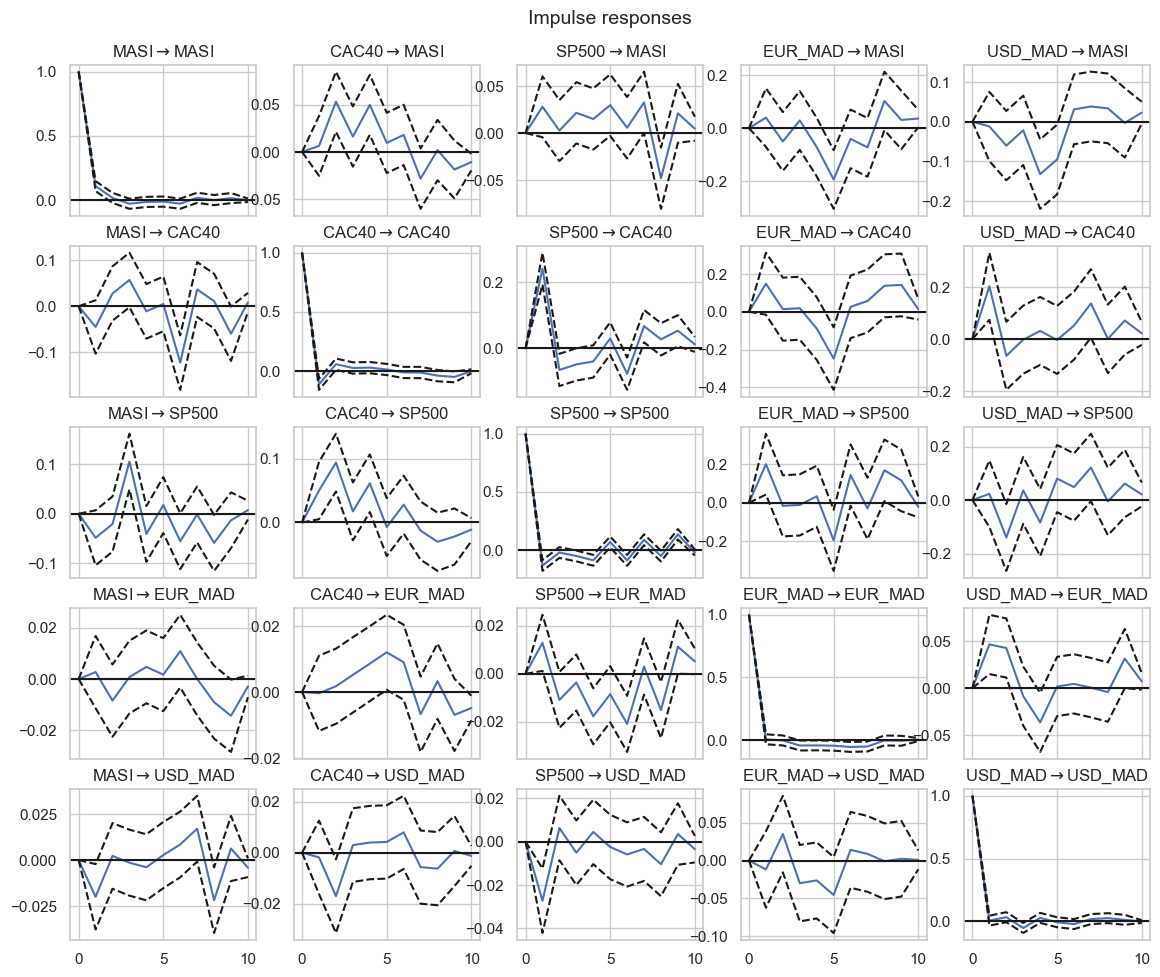

In [17]:
irf = impulse_response_analysis(var_results, periods=10)
fig = irf.plot(orth=False)
fig.set_size_inches(12, 10)
fig.savefig(FIGURES_DIR / "var_impulse_response_functions.png", dpi=300, bbox_inches="tight")
plt.show()

## Forecast Error Variance Decomposition

FEVD describes how much of each variable's forecast error variance is explained by shocks to itself and other variables.

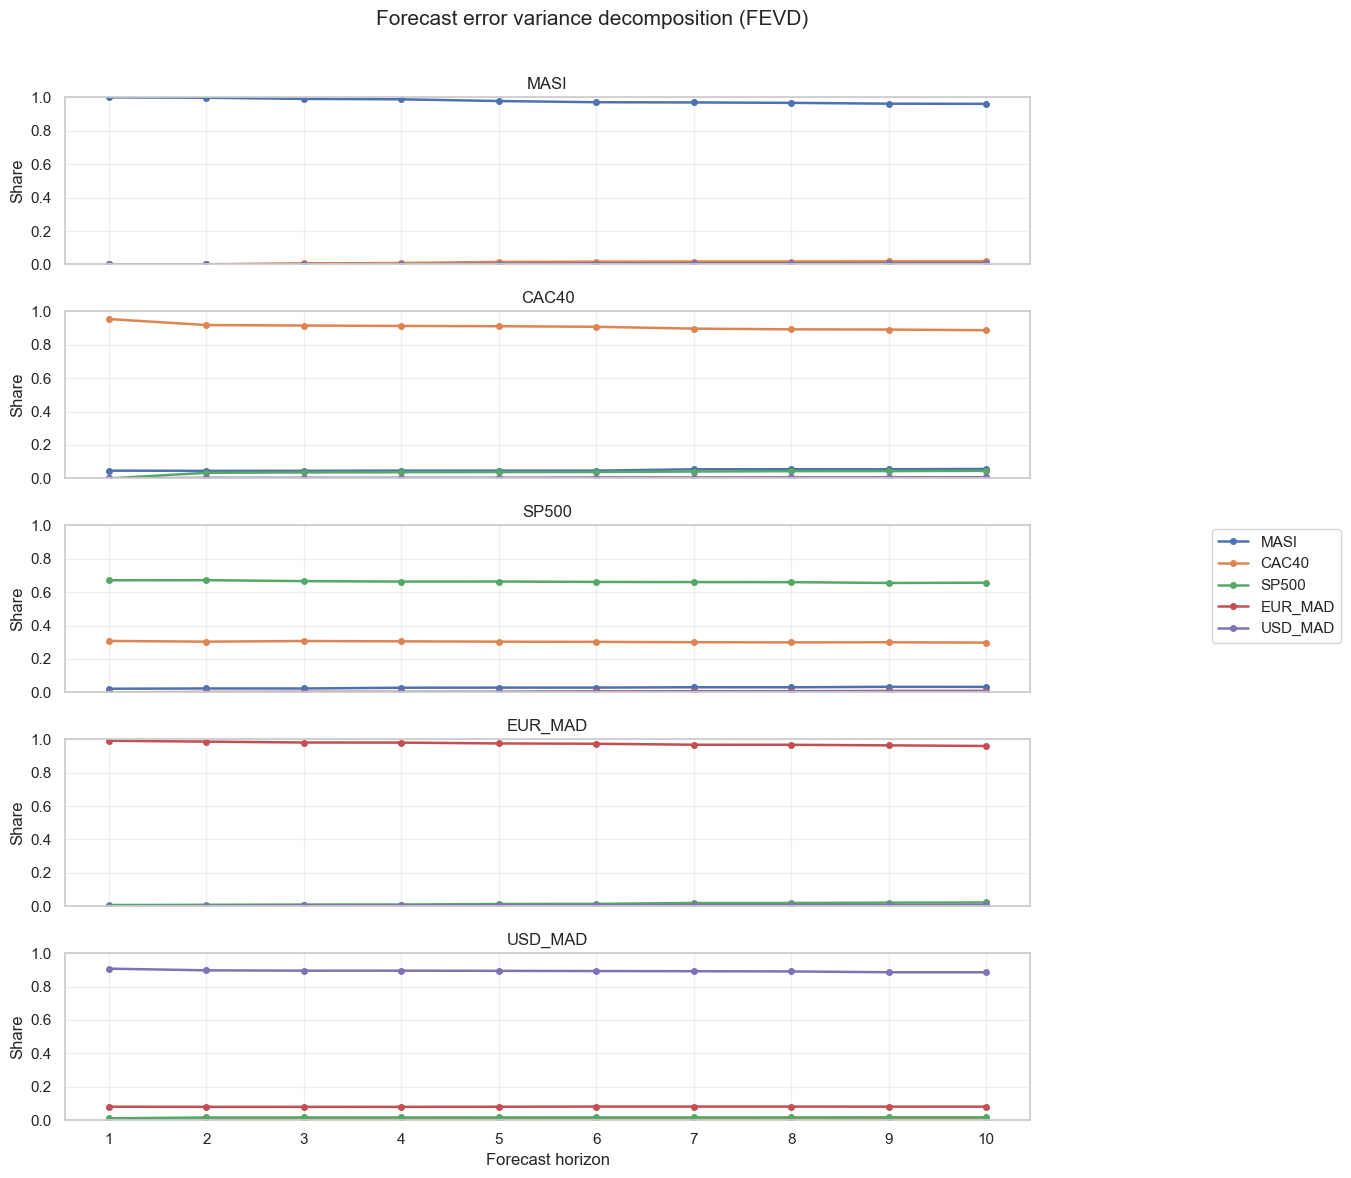

In [18]:
fevd = variance_decomposition(var_results, periods=10)
horizons = np.arange(1, fevd.decomp.shape[1] + 1)
fig, axes = plt.subplots(
    len(fevd.names), 1, figsize=(12, 12), sharex=True, sharey=True
)

for response_index, (response, ax) in enumerate(zip(fevd.names, axes)):
    for shock_index, shock in enumerate(fevd.names):
        ax.plot(
            horizons,
            fevd.decomp[response_index, :, shock_index],
            marker="o",
            linewidth=1.8,
            markersize=4,
            label=shock,
        )
    ax.set_title(response)
    ax.set_ylabel("Share")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Forecast horizon")
axes[-1].set_xticks(horizons)
fig.suptitle("Forecast error variance decomposition (FEVD)", fontsize=15)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.97))
fig.savefig(FIGURES_DIR / "var_variance_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()

## VAR Diagnostics

A well-behaved VAR should be stable and should not leave strong autocorrelation in residuals. Residual normality is often rejected in financial data because returns are fat-tailed.

In [19]:
diagnostics = summarize_var_diagnostics(var_results)
diagnostics.to_csv(RESULTS_DIR / "var_diagnostics.csv", index=False)
diagnostics

,diagnostic,statistic,p_value,conclusion
0,VAR stability,NaN,NaN,Stable
1,Residual autocorrelation,186.602165,0.000297,Residual autocorrelation detected
2,Residual normality,34826.618213,0.000000,Reject normality


## Optional Robustness Check: MASI Equation

The following check compares a one-equation OLS regression with a robust linear model for MASI using one-period lags of all variables. This is not a full VAR-Gini estimator; it is a practical sensitivity check for the MASI equation.

In [20]:
lagged = var_data.shift(1).add_suffix("_lag1")
masi_equation_data = pd.concat([var_data["MASI"].rename("MASI"), lagged], axis=1).dropna()

y = masi_equation_data["MASI"]
X = sm.add_constant(masi_equation_data.drop(columns="MASI"))

ols_model = sm.OLS(y, X).fit()
rlm_model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()

robust_comparison = pd.DataFrame({
    "OLS coefficient": ols_model.params,
    "OLS p-value": ols_model.pvalues,
    "RLM coefficient": rlm_model.params,
})
robust_comparison.to_csv(RESULTS_DIR / "masi_equation_ols_rlm_comparison.csv")
robust_comparison

,OLS coefficient,OLS p-value,RLM coefficient
const,0.000224,1.389542e-01,0.000242
MASI_lag1,0.123941,2.445268e-10,0.076761
CAC40_lag1,0.009828,5.186334e-01,0.021670
SP500_lag1,0.011358,4.686989e-01,0.020305
EUR_MAD_lag1,0.040728,4.623934e-01,-0.026892
USD_MAD_lag1,-0.016216,7.114569e-01,-0.012071


## Robustness Discussion: Why VAR-Gini Matters

Financial data often contain outliers caused by market stress, currency shocks, liquidity events, policy news, or data-frequency mismatches. Classical VAR uses OLS equation by equation, so extreme observations can have disproportionate influence on coefficients, standard errors, impulse responses, and Granger causality conclusions.

The motivating scientific article uses VAR-Gini to improve robustness in the presence of outliers. VAR-Gini replaces classical least-squares sensitivity with a more robust dependence structure, making it attractive for financial data that violate Gaussian assumptions.

This project does not fully implement VAR-Gini. Instead, it prepares the foundation for robust econometric analysis by cleaning financial data, measuring non-normality, detecting outliers, checking stationarity and cointegration, estimating a classical VAR, and adding a practical robust linear model comparison for the MASI equation.

## Financial Interpretation

The targeted Granger table should be interpreted around the research question: whether S&P500, CAC40, USD/MAD, and EUR/MAD returns contain predictive information for MASI returns, and whether MASI feeds back into exchange-rate movements. Significant results suggest short-run predictive linkages. Non-significant results indicate that, within the chosen lag structure and sample, the source variable does not add statistically detectable predictive content beyond the rest of the VAR system.